<a id="T_ADCD62AB"></a>

# <span style="color:rgb(213,80,0)">Part I: Introduction to Battery Modelling with BattMo</span>

 **Dr. Sridevi Krishnamurthi** and **Dr. Simon Clark,** *SINTEF AS, Battery Technology, Trondheim, Norway*

This guide provides an introductory resource for readers who would like to learn about lithium\-ion batteries, battery modelling, or both! Starting from the basics of how a Li\-ion battery works, we go step\-by\-step, introducing new modelling concepts at each level. After completing this guide, readers should have a working knowledge of Li\-ion battery design principles and be able to simulate a variety of designs under different conditions.

The guide is divided into four parts:

- **Part I: Introduction to Battery Modelling with BattMo** introduces the basic concepts of Li\-ion battery design and operation. This part introduces the types of simulations that BattMo can perform and provides some examples demonstrating simple design modifications
- **Part II: The DFN Model overview** explains how the model operates and examines how the model parameters influence cell capacities.
- **Part III: Engineering** use cases delves into the cell design problems such as electrode balancing, rate capability analysis
- **Part IV: Ageing mechanisms and cell engineering** discusses the SEI and Lithium plating issues as part of the ageing mechanism, we also intoduce P4D models for dealing with complex geometries.

*Please run 'startupBattMo.m' present in the home folder before running this notebook, this loads all the neccessary modules for running the simulations.*

Rechargeable Li\-ion batteries have transformed our lives. With the current focus on electrifying the mobility sector and the growing need to support intermittent renewable energy sources, there is much to learn about batteries and the materials that make them. The goal is to develop batteries with higher energy density and improved safety, manufactured in a sustainable manner.

BattMo is a powerful tool for conducting battery simulations, aiding in the understanding and optimization of battery performance. It utilizes continuum scale PXD (pseudo\-X\-dimensional) simulations based on the Doyle\-Fuller\-Newman (DFN) model. By providing material and design parameters for the various components of the battery, BattMo can simulate how key quantities like voltage, current, concentration, and temperature change in the battery as it is operated. When simulated over many charge\-discharge cycles, BattMo can also predict capacity losses that occur due to degradation. It supports simulations from simple 1D grids to complex multi\-layer pouch cells and jelly rolls, incorporating thermal effects and degradation mechanisms. Its modular design facilitates easy switching between different cell chemistries, making BattMo versatile for applications in battery research and development.

For a detailed overview of the modelling approach and the DFN model, please refer to  **Part II** of this modelling guide.

<a id="H_16F529FF"></a>

## **1. Lithium\-Ion Battery Basics**

Let's begin by exploring some lithium\-ion (Li\-ion) battery basics. The battery cell consists of three main components: **a negative electrode**, **a positive electrode**, and **an electrolyte**.

Each electrode contains an **active material** that stores energy by incorporating lithium into its chemical structure through an electrochemical reaction like intercalation or alloying. There are a variety of materials that could be used for active materials, but typical Li\-ion batteries use graphite for the negative electrode and a lithiated transition metal oxide for the positive electrode. The active materials act as a stable host structure for storing Li\-ions. You can think of them like shelves and the Li\-ions like boxes. Boxes can be moved from one shelf to another, but the shelf itself remains stable.

The electrodes are linked by an electrolyte that serves as a type of "highway" for transporting Li+ ions, and it typically consists of a lithium salt like LiPF6 dissolved in a carbonate\-based solvent. The electrolyte must support the fast transport of ions, while also blocking the transport of electrons. The electronically insulating nature of the electrolyte forces the electrons through an external circuit, providing electrical energy to connected devices. We will look at the exact types of materials used for these components later.

A schematic overview of this process for a graphite \- lithium cobalt oxide (LCO) cell is shown in **Figure 1**. The basic operating principle of the Li\-ion battery is sometimes refered to as a "rocking\-chair" mechanism, because the rock back\-and\-forth between the positive and negative electrodes. When the Li\-ion battery cell is charged, an externally applied voltage drives Li+ to de\-intercalate from the positive electrode into the electrolyte where they are transported via diffusion\-migration to the negative electrode. Electrons are released from the oxidation of cobalt in the positive electrode (Co3+ \-> Co4+), travel through the external circuit, and recombine with lithium in the negative electrode \[1\]. When the Li\-ion battery cell is discharged, the process is reversed. Driven by the change in the Gibbs Free Energy, Li is oxidized in the negative electrode and is transported across the electrolyte where it combines with electrons from the external circuit and is intercalated back into the positive electrode active material.

<p style="text-align:left">
   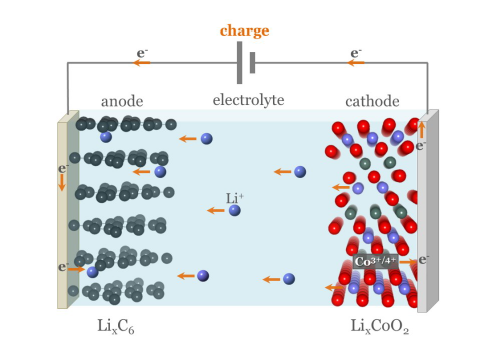
</p>

 **Figure 1: A schematic representation of a typical Li\-ion cell during charging.**  *The Li\-ion cell is a stack of a negative electrode, a positive electrode, and a Li+ containing electrolyte. The Li\-ion cell works on the principle of intercalation, where Li+ ions are inserted into vacant sites in the electrode active materials. While a variety of active materials could be used for the electrodes, typical Li\-ion batteries use graphite for the negative electrode and a lithiated transition metal oxide like LiCoO2 for the positive electrode \[1\].*

<a id="H_EBB7A2BD"></a>

###  **1.1 Cell Components**

Lithium\-ion battery electrodes are porous composite structures that consist of a mixture of **active material**, **binder**, and **conducting additives** applied as a coating on a foil **current collector**. When the cell is assembled, the electrolyte is injected into the device and fills up the pores in the electrode, creating interfaces with the active materials where the electrochemical reactions can take place.

<p style="text-align:left">
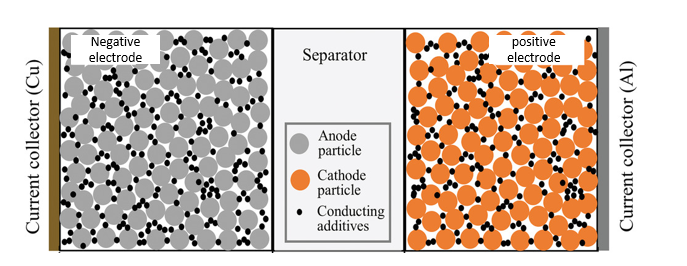
</p>

**Figure 2:** **Cross\-sectional layout of a LIB with two porous electrodes and a porous separator.** *The active materials in the anode (negative electrode) and cathode (positive electrode) are simplified to spherical particles with gray and orange colors. The conducting additives are simplified to black small particles \[6\].*

<a id="H_0F83C2CE"></a>
**Positive Electrode**

Active materials for positive electrodes in Li\-ion batteries are lithium transition metal oxides, which come in a variety of different compositions and crystal structures. The most common oxides NMC (lithium nickel manganese cobalt oxide), LFP (lithium iron phosphate), LMO (Llithium manganese oxide), LNO (lithium nickel oxide) LCO (lithium cobalt oxide) and NCA (lithium nickel cobalt aluminium oxide). Because these materials differ in energy density, cycling stability, commercial availability, and environmental impact, selecting the appropriate one for each application is crucial.  For a thorough review of positive electrode materials, the reader can refer [here](https://www.nature.com/articles/s41467-020-15355-0).

<p style="text-align:left">
   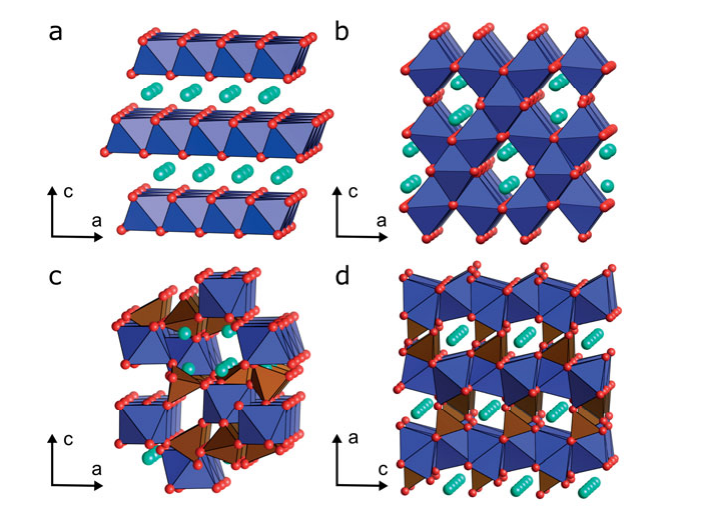
</p>

 **Fig. 3:** .**Crystal structures of transition metal oxides used as positive electrode active materials:**  *(a) layered LiMO2 (M = Co, Ni, Mn, etc.), (b) spinel LiMn2O4, (c) NASICON\-type Li3Fe2(PO4)3, and (d) olivine LiFePO4. The transition metal octahedra, MO6, are represented in blue, while the polyanion tetrahedra, XO4, are represented in brown. Li\-ions are shown in turquoise\[7\].*

<a id="H_030B217D"></a>
**Negative Electrode**

Graphite is the most common active material for the negative electrode in Li\-ion cells, although alternative materials like silicon (Si) and lithium titanate (LTO) are used for some specialty applications. Early versions of rechargeable lithium batteries used lithium metal as the negative electrode active material due to its high specific capacity. However, ltihium metal can form dendritic or needle\-like structures during charging, which can cause to safety\-critical internal short\-circuits. Nonetheless, research and development of lithium metal systems with advanced electrolytes continues as a way to increase the specific energy / energy density of rechargeable batteries. For a review on on carbon based negative electrode materials, one can refer [here](https://www.sciencedirect.com/science/article/pii/S2352152X23001135).

<a id="H_E09B5E65"></a>
**Electrolyte**

The electrolyte serves as the medium for Li\-ion conduction and can be either solid or liquid. Liquid electrolytes typically consist of lithium salts dissolved in an organic solvent, with common examples being LiPF6, LiBF4, and LiClO4. Commonly used solvents are ethylene carbonate, dimethyl carbonate, and diethyl carbonate. A good electrolyte, whether solid or liquid must possess high ionic conductivity, low electronic conductivity, support high voltages, and remain stable across a wide temperature range. For a review on liquid electrolytes, one can refer [here](https://onlinelibrary.wiley.com/doi/full/10.1002/smll.202205315).

<a id="H_A5866963"></a>
**Separator**

The separator is typically made from polymer materials such as polyethylene (PE) or polypropylene (PP). It serves as a porous medium allowing lithium ions to move between the positive and negative electrodes. While the separator itself does not participate in the electrochemical reactions, it can influence the safety, power density, and cycle life of the battery.

<a id="H_62277726"></a>

### **1.2 Working Principle**

During charging, lithium ions (Li+) are deintercalated from the positive electrode (in this example, NMC) and migrate to the negative electrode (in this example, graphite) through the electrolyte. Concurrently, electrons are driven through the external circuit from NMC to graphite. During discharging, the reverse process occurs: lithium ions migrate back from the negative electrode (graphite) to the positive electrode (NMC) through the electrolyte, while electrons flow from graphite to NMC through the external circuit.

  **At the positive electrode:**

 $\textrm{Li}{\textrm{[NiMnCo]O}}_2 \overset{\textrm{charge}}{\underset{\textrm{discharge}}{\rightleftharpoons} } {\textrm{Li}}_{(1-x)} {\textrm{[NiMnCo]O}}_2 +x{\textrm{Li}}^+ +x{\textrm{e}}^-$ (1.1)

**At the negative electrode:**

 ${\textrm{C}}_6 +y{\textrm{Li}}^+ +{\textrm{e}}^- \overset{\textrm{charge}}{\underset{\textrm{discharge}}{\rightleftharpoons} } {\textrm{Li}}_y {\textrm{C}}_6$  (1.2)

**The overall cell reaction:**

 ${\textrm{[LiNiMnCo]O}}_2 +{\textrm{C}}_6 \overset{\textrm{charge}}{\underset{\textrm{discharge}}{\rightleftharpoons} } +{\textrm{Li}}_{1-x} {\textrm{[NiMnCo]O}}_2 +{\textrm{Li}}_y {\textrm{C}}_6$ (1.3)

The system is at its lowest energy when the Li\-ions are in the positive electrode, during discharge, the Li ions migrate from the negative electrode to the positive electrode and the potential difference is released as energy. A detailed thermodynamic description will be presented in part 2 of the guide.

<a id="H_E9D769CA"></a>

### 1.3 Battery Properties

A good battery should posess high energy density, ensuring it can store a significant amount of energy relative to its size and weight. Additionally, it should maintain a long cycle life, allowing it to endure numerous charge and discharge cycles without significant degradation. Minimal energy loss during these cycles is crucial, ensuring efficient energy usage and prolonged operational efficiency.

Let's delve into essential terms and parameters crucial for understanding batteries and their simulation in BattMo. These help in evaluating and comparing battery performance and characteristics.

**Definitions:**

- [Lower](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_534dd59c_904c_45d9_8550_ae9d2eb6bbc9>) ([upper](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_6dcd5baf_58cd_43f5_a692_51508e036c88>)) voltage limit:The minimum (maximum) allowable voltage. It is this voltage that generally defines the “empty” ("full") state of the battery, this is set as an input parameter in the simulation.The value depends on the cell chemistry.
- [C\-Rate](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_e1fd84eb_acdb_4b2c_b90c_e899d552a3ee>) (cycling rate): this is the rate at which a battery is discharged in relation to its maximum capacity. Specifically, a 1C rate signifies that the discharge current will exhaust the total battery capacity in 1 hour. The CRate chosen depends on your application, this is set as an input parameter in the simulation
- [State of Charge (SOC %)](<https://w3id.org/emmo/domain/battery#battery_17591da0_34ec_41b9_b3c1_3a4446dc6f0a>): ratio of the current battery capacity to its maximum capacity, this is set as an input parameter in the simulation
- [Open\-Circuit Voltage](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_9c657fdc_b9d3_4964_907c_f9a6e8c5f52b>) (OCV): The voltage between the positive electrode and the negative electrode with no external load, to calculate this in BattMo,one can use a very small charge/discharge current, a CRate of C/20. OCV curves are typically plotted as voltage versus state of charge (SOC), the curves depend on the chemistry of the cell.

**Cell Properties:**

- [Capacity](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_791c1915_a791_4450_acd8_7f94764743b5>) / Ah: electric charge which a cell or battery can deliver under specified discharge conditions, calculated as a product of discharge current and discharge time. Increasing the CRate decreases the capacity due to increasing internal losses.
- [Nominal Capacity](<https://w3id.org/emmo/domain/battery#battery_fb9baf9b_680e_493e_a755_da9bb1fc9fae>) / Ah: the rated capacity that is representative of the typical value associated with a cell as stated by the manufacturer
- [Theoretical Capacity](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_b7781ebc_90a7_4f19_997f_aed28dee1b01>) / Ah: maximum possible charge, a cell can store, it is a fixed value determined by the amount and type of active material used in the electrodes.
- [Energy](<https://w3id.org/emmo/domain/battery#battery_87bb15ff_4fc2_4929_9938_0b31d9166001>) / Wh: calculated as the product of capacity and the average discharge voltage when discharged at a specific C\-rate,Increasing the CRate decreases the energy.
- [Energy Density](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_4aa1b96e_44a0_4b1a_a0ac_723d0223d80b>) / Wh/L: calculated as the energy divided by the volume of the cell
- [Specific Energy](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_5e4490b8_c1dd_4e00_980b_c484e1bf4904>) / Wh/kg: calculated as the energy divided by the mass of the cell
- [Round\-Trip Efficiency](<https://w3id.org/emmo/domain/electrochemistry#electrochemistry_79198264_cdf5_4fc3_8bcf_e5140a52547a>): ratio of the energy released during discharge to the energy stored during charge. This parameter indicates how effectively a battery converts stored energy into usable energy.

<a id="H_1A7D051D"></a>

### **1.4 Operational Protocols**

In BattMo, we set the protocols for the charging and discharging of the cell using the [control model schema](<<https://battmoteam.github.io/BattMo/controlinput.html#control-models>>). We discuss the basic protocols here:

<a id="H_61197C3C"></a>
- **Constant Current Discharging.** During discharge, a constant current (CC) based on the chosen C\-rate is drawn from the cell until the voltage reaches the minimum cut\-off voltage (lowerCutoffVoltage) of the cell.
- **Constant Current Constant Voltage Charging.** A Li\-ion battery is typically charged using a constant current/constant voltage protocol (CC\-CV). This means the battery is initially charged at a constant current until it reaches a maximum voltage (upperCutoffVoltage). Once this voltage is reached, the protocol switches to maintaining a constant voltage between the terminals while the charging current gradually decreases.

<a id="H_CAD99AA6"></a>

## **2. Modelling with BattMo**

BattMo comes with several default material and cell parameter sets; for more details, refer [here](https://github.com/BattMoTeam/BattMo/tree/main/ParameterData/ParameterSets). Users can also input their own parameterization data. BattMo uses the JSON (JavaScript Object Notation) format to manage input parameters. This allows you to easily save, document, and share complete parameter sets from specific simulations. If you are new to JSON, you can learn more about it [here](https://www.w3schools.com/js/js_json_intro.asp).

For the rest of this guide, we will use a starter JSON file, [sample\_input.json](https://github.com/BattMoTeam/BattMo/blob/main/Examples/JsonDataFiles/sample_input.json) that describes a lithium nickel manganese cobalt oxide (NMC 811) \- graphite cell \[2\] with LiPF6 \[3\] as the electrolyte, in a 1D cell according to BattMo['s JSON input specification](<https://battmoteam.github.io/BattMo/json.html#json-input-specification>).

This sample\_input.json file contains all the information needed to run the simulation. These parameters are neatly arranged into structured schemas. Unless otherwise specified, BattMo uses [SI base units](https://www.nist.gov/si-redefinition/definitions-si-base-units) for physical quantities.

**Input schema:**

- A schema for the [**geometry**](<https://battmoteam.github.io/BattMo/geometryinput.html#batterygeneratorp2d>) **,** contains the dimensions of the whole cell and the different components within the cell.
- A schema for the [**battery cell material parameters**](<https://battmoteam.github.io/BattMo/json.html#material-parameters>) **,** contains material parameters for the NMC \- Graphite cell sourced from the literature.
- A schema for the **initialization of the state of the battery,** specifies the initial state of the battery, including the initial state of charge (SOC).
- A schema for the [**control model**](<<https://battmoteam.github.io/BattMo/controlinput.html#control-models>>), defines the charging and discharging protocols,
- A schema for the [**time stepping**](<https://battmoteam.github.io/BattMo/json.html#time-stepping-parameters>)**,**
- A schema for the [**solver parameters**](<https://battmoteam.github.io/BattMo/json.html#time-stepping-parameters>) **,** specifies the parameters for the numerical solver used in the simulation.
- A schema for the [**output specification**](<https://battmoteam.github.io/BattMo/json.html#output-parameters>)

<a id="H_77293B55"></a>

### **2.1 P2D/P3D/P4D Models**

As previously mentioned, BattMo utilizes the DFN model, which can be applied across different grid dimensions, ranging from P2D to P4D. The P2D model simulates battery properties along the thickness direction on a macroscopic scale while neglecting in\-plane variations, essentially representing a 1D geometry, hence the term "pseudo\-2D."  The equations governing the P2D model will be detailed in the second part of the modelling guide. While the P2D model provides a sufficient approximation in many cases, it cannot capture the full complexity of a real battery cell. To address this, the P3D/P4D models incorporate additional spatial dimensions for higher resolution. However, this increased resolution also results in longer computation times and higher computational demands.

BattMo offers grid generator functions that create battery geometries ranging from P2D to P4D and configures the grid for calculations according to the specified input dimensions and discretization parameters. For more details, see [here](https://battmoteam.github.io/BattMo/geometryinput.html).

 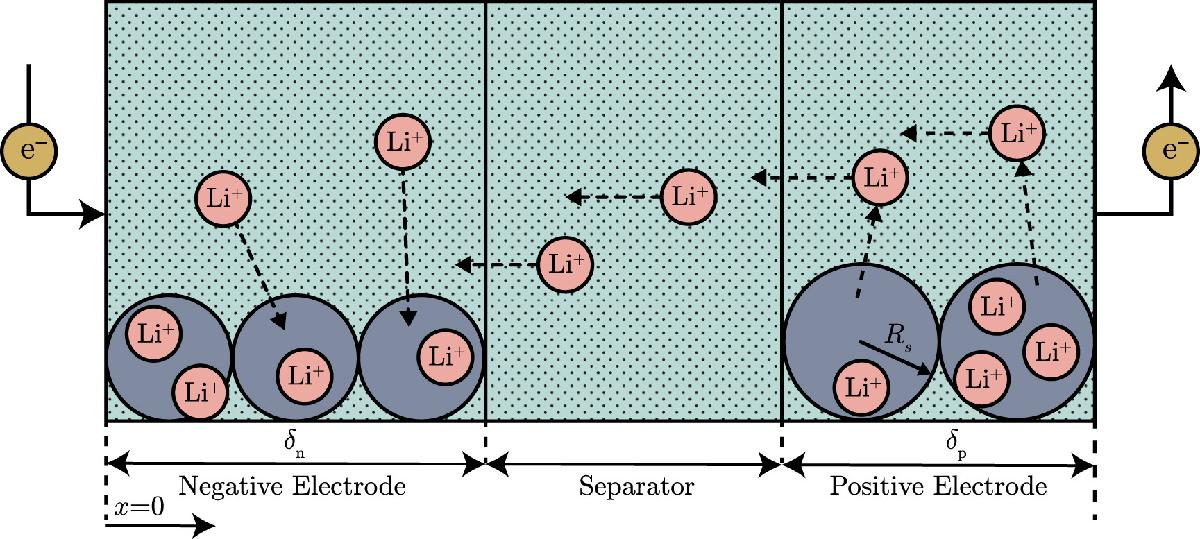

**Figure 4: A schematic representation of the P2D model.** *The cell is divided into three regions: the positive and negative electrodes, depicted as spherical particles, and the electrolyte, which fills the spaces between these particles. The figure illustrates the charging process, showing Li\-ions deintercalating from the positive electrode particles and migrating to the negative electrode spheres \[5\].*

<a id="H_A471E12B"></a>

#### **Example 1. Build and Visualize the Battery Grid in 3D**

As the first step in modeling, let’s examine how a battery is represented in BattMo in a 3D grid. There are convenient built\-in functions that help in parsing and visualizing data.

- Load the default sample\_input.json file using parseBattmoJson function.
- Merge the default file with a 3D Geometry File with mergeStructs and visualise a 3D battery cell using plotBatteryGrid.


In [1]:
jsonstruct_default = parseBattmoJson('Examples/JsonDataFiles/sample_input.json');
jsonstruct_3d_geometry = parseBattmoJson('Examples/JsonDataFiles/geometry3d.json');
jsonstruct_modified_3d = mergeStructs({jsonstruct_3d_geometry , ...
    jsonstruct_default});

mergeStructs: Parameter include_current_collectors is assigned twice with different values. Value from first jsonstruct is used.
mergeStructs: Parameter Geometry.case is assigned twice with different values. Value from first jsonstruct is used.
mergeStructs: Parameter NegativeElectrode.Coating.thickness is assigned twice with different values 0.0001 and 6.4e-05, relative difference is 0.219512. Value from first jsonstruct is used.
mergeStructs: Parameter NegativeElectrode.Coating.numberOfDiscreteCells is assigned twice with different values 3 and 10, relative difference is 0.538462. Value from first jsonstruct is used.
mergeStructs: Parameter NegativeElectrode.CurrentCollector.numberOfDiscreteCells is assigned twice with different values 2 and 10, relative difference is 0.666667. Value from first jsonstruct is used.
mergeStructs: Parameter PositiveElectrode.Coating.thickness is assigned twice with different values 8e-05 and 5.7e-05, relative difference is 0.167883. Value from first jso


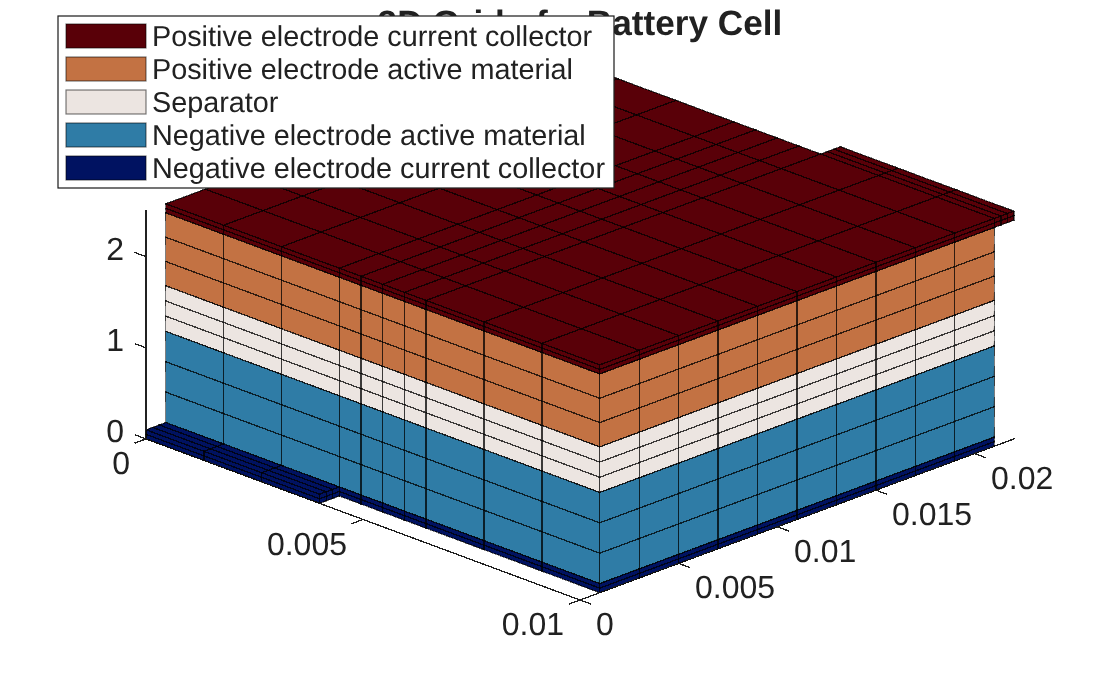

In [2]:
model_3d = setupModelFromJson(jsonstruct_modified_3d);
plotBatteryGrid(model_3d);
axis tight
view(45,45)
set(gca, 'FontSize', 12)
legend('Position', [0.15, 0.8, 0.3, 0.1]);
title('3D Grid of a Battery Cell')

<a id="H_3415FA0F"></a>

#### **Example 2. Constant Current Discharging of a Gr\-NMC Battery Cell in 1D geometry**

Now we are ready to run our first simulation. Refer to the `[sample_input.json](https://github.com/BattMoTeam/BattMo/blob/main/Examples/JsonDataFiles/sample_input.json)` for the exact input values. In summary, we will simulate the constant current (CC) discharge of an NMC\-Graphite system, starting from a 100% state of charge (SOC) at a C\-rate of 1. For the sake of the tutorial, we will make use of the 1D geometry and run P2D simulations,  Let us visualise this system first,



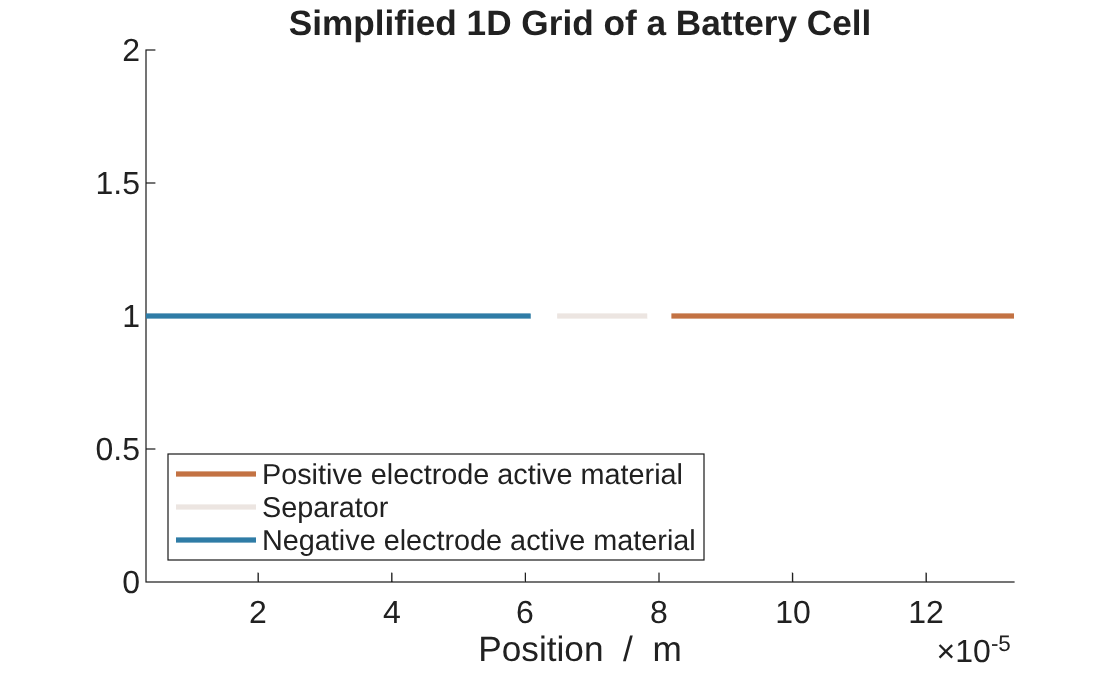

In [3]:
jsonstruct_default = parseBattmoJson('Examples/JsonDataFiles/sample_input.json');
model_1d = setupModelFromJson(jsonstruct_default);


% use the plotBatteryGrid function to show the grid
plotBatteryGrid(model_1d);
axis tight
set(gca, 'FontSize', 12)
xlabel('Position  /  m')
title('Simplified 1D Grid of a Battery Cell')


Before running the actual simulation, the function `computeCellCapacity.m` processes the material parameters for the active materials in the electrodes, along with their mass fractions, to compute the maximum cell capacity (theoretical capacity). Using this capacity, the program sets the discharge current accordingly ( $\textrm{capacity}=\frac{1}{\textrm{C}\textrm{-}\textrm{rate}}\times \textrm{discharge}\;\textrm{current}$ )

For this system, the typical lower and upper cutoff voltages are 2.4 V and 4.1 V, respectively. The simulation stops when the lower cut\-off voltage is reached.


In [4]:
jsonstruct = parseBattmoJson('Examples/JsonDataFiles/sample_input.json');% parse the sample_input.json
disp(jsonstruct.Control);% see the default values set in the control policy

         controlPolicy: 'CCDischarge'
                 DRate: 1
    lowerCutoffVoltage: 3
    upperCutoffVoltage: 4.1000
             dIdtLimit: 0.0100
             dEdtLimit: 0.0100
            rampupTime: 0.1000


The simulation can then be executed using the `runBattery` function.


In [5]:
jsonstruct.TimeStepping.totalTime = (1./jsonstruct.Control.DRate) .* 3600 .* 1.2; % setting the total time of the simulation to be a little over 1 hour for a C-rate/D-rate of 1.
output_dis_NMC = runBattery(jsonstruct);


The output matrix returns among other things the model and the states. The model contains information about the setup of the model and initial conditions, while states contains the results of the simulation at each timestep. The model can also output the energy, energy density and specific energy of the system.


In [6]:
disp(output_dis_NMC);

             model: [1x1 GenericBattery]
       inputparams: [1x1 BatteryInputParams]
          simsetup: [1x1 SimulationSetup]
        jsonstruct: [1x1 struct]
              time: [133x1 double]
                 E: [133x1 double]
                 I: [133x1 double]
          globvars: {133x1 cell}
            states: {133x1 cell}
            energy: [132x1 double]
     energyDensity: [132x1 double]
    specificEnergy: []


The `plotDashboard` function displays the Li\-ion concentration profile in both the solids and electrolytes, as well as the electrode potentials at a specific time step.

The concentration profiles help understand how efficiently the intercalation (and deintercalation) processes have occurred. They can identify performance issues such as lithium plating or irreversible lithium loss.



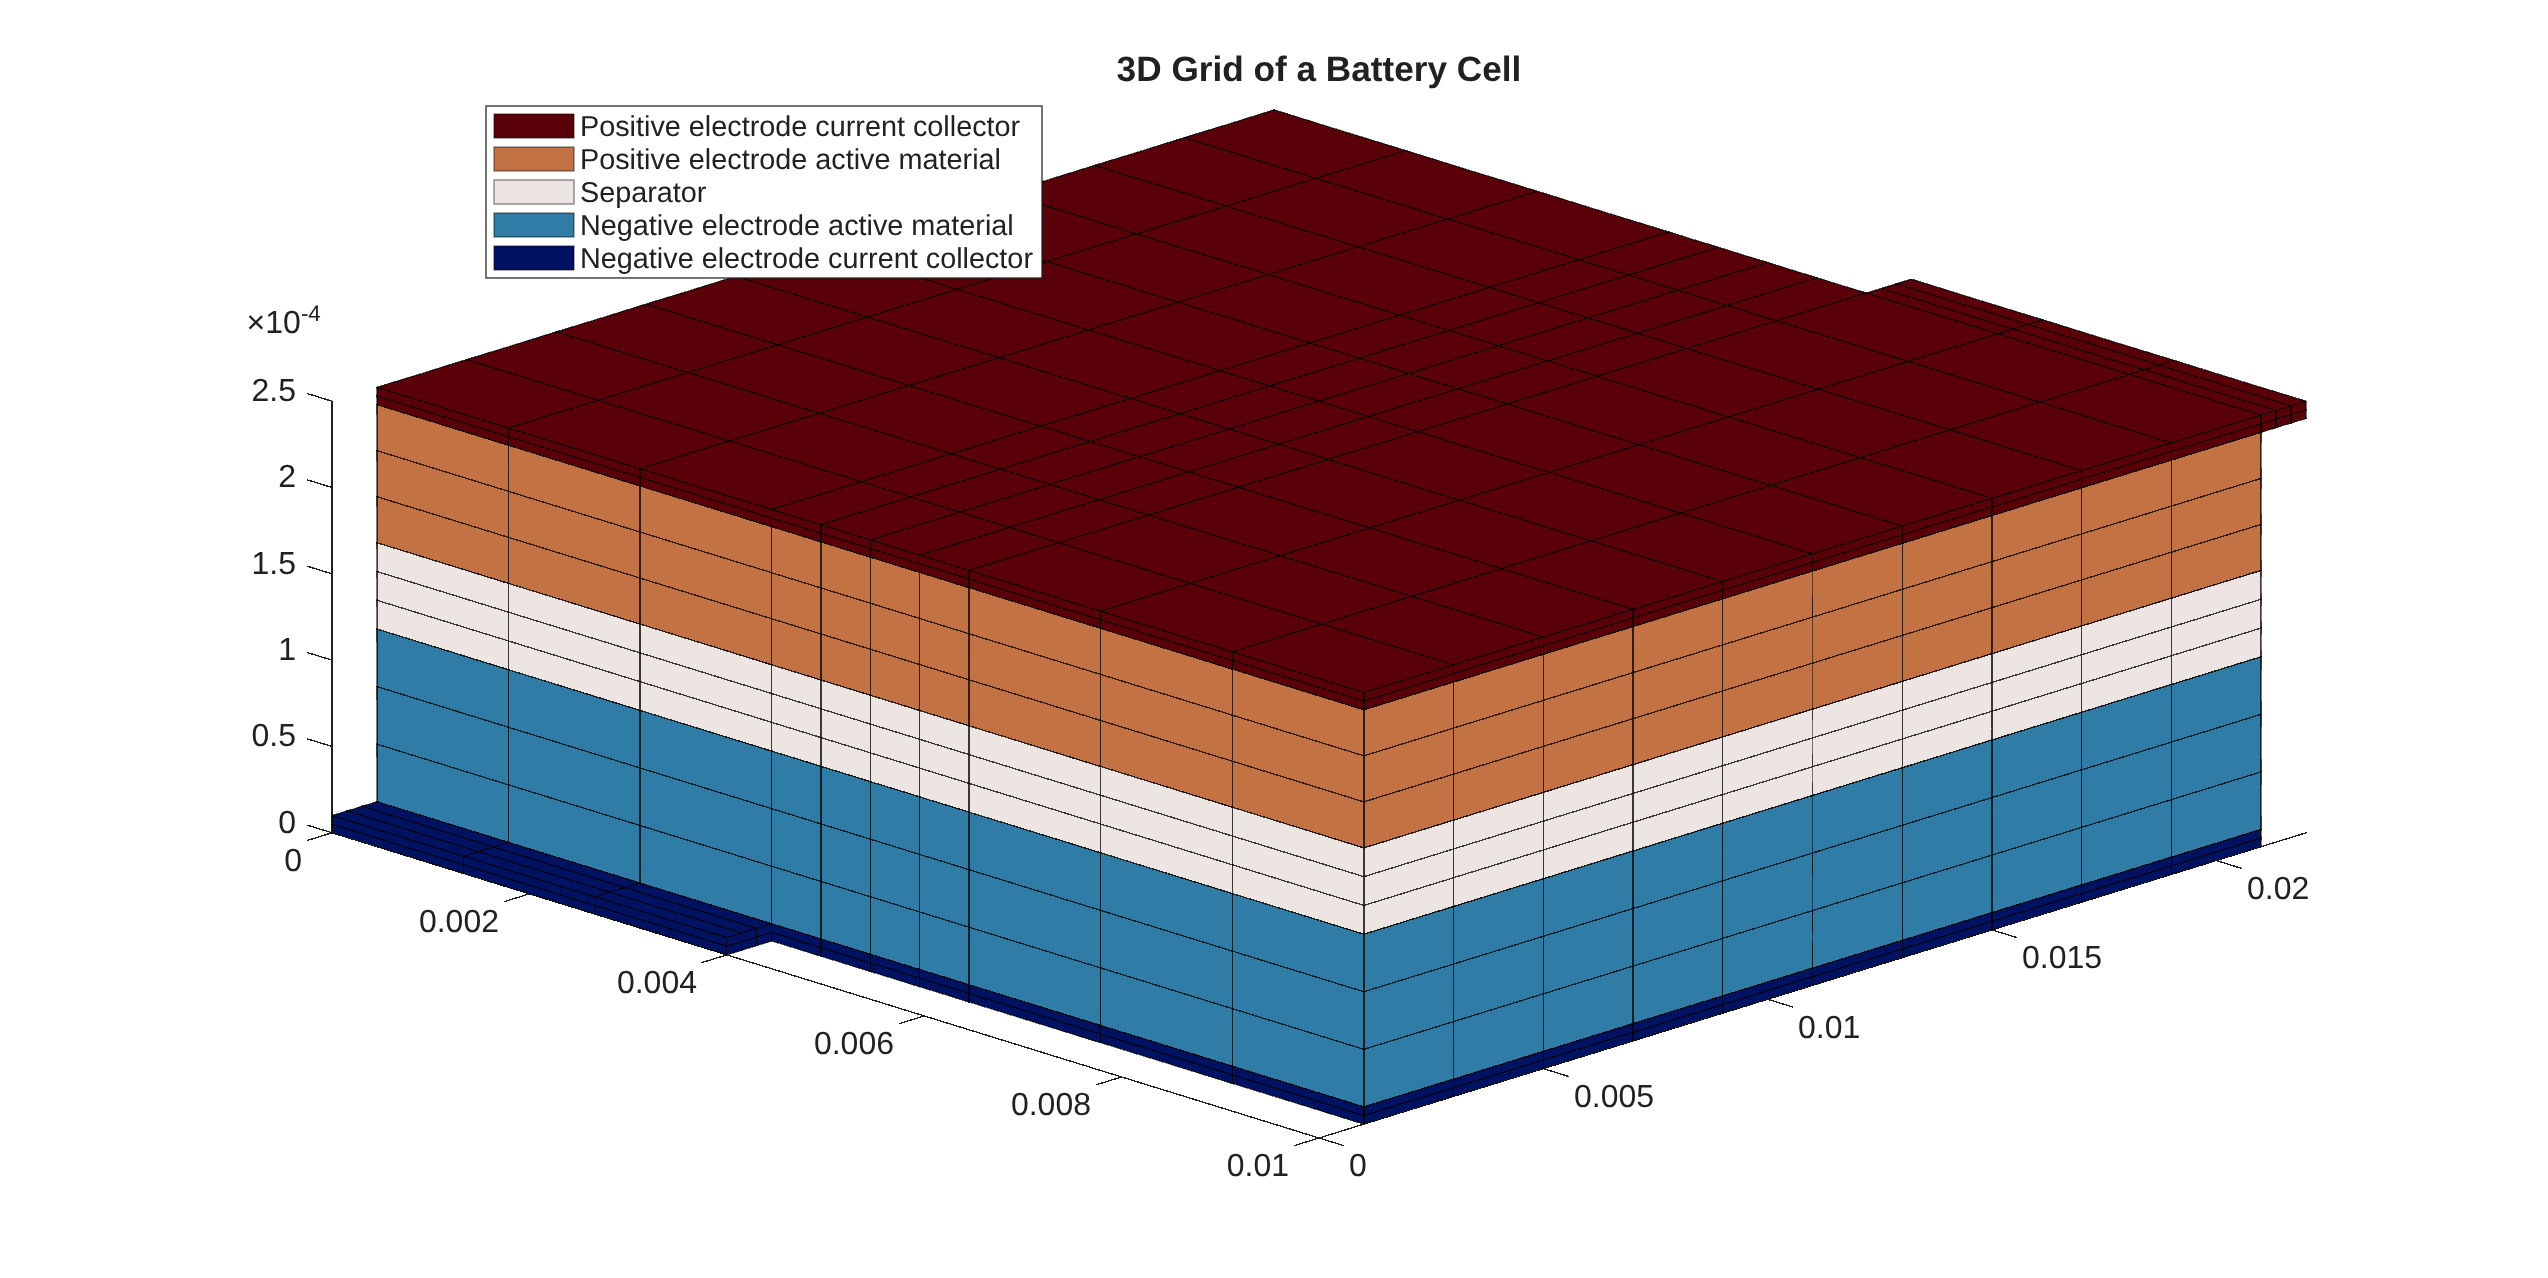


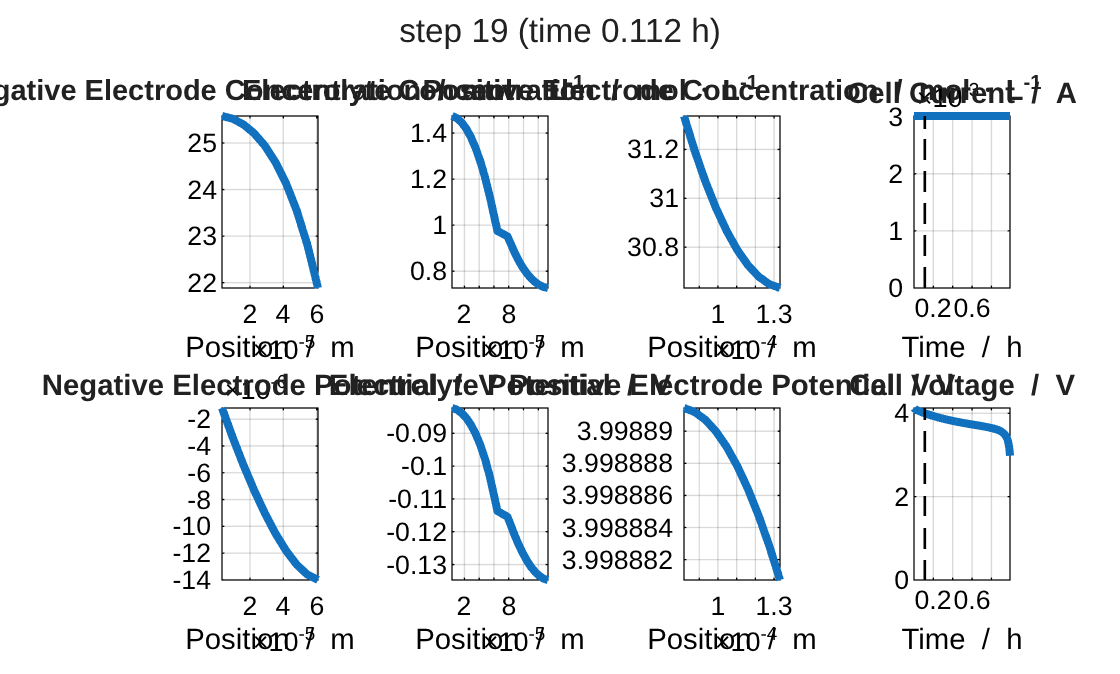

In [7]:
step_number = 19;
plotDashboard(output_dis_NMC.model, output_dis_NMC.states, 'step', step_number);

<a id="H_34D8A9B6"></a>

#### **Example 3. Post\-Processing Voltage Curves**

Let's examine the voltage versus capacity curve, which represents the cell discharge profile. The voltage curve typically exhibits three distinct segments:

- An initial drop, caused by internal resistances and the activation of electrochemical processes.
- A gently sloping or plateau region where the voltage remains relatively stable. A longer plateau region in a battery's discharge profile is beneficial as it signifies that the voltage remains stable with minimal fluctuations across a substantial portion of its capacity, ensuring consistent and efficient energy delivery. The length and voltage of this plateau depend on the cell chemistry.
- A final drop as the cell approaches its capacity limit.



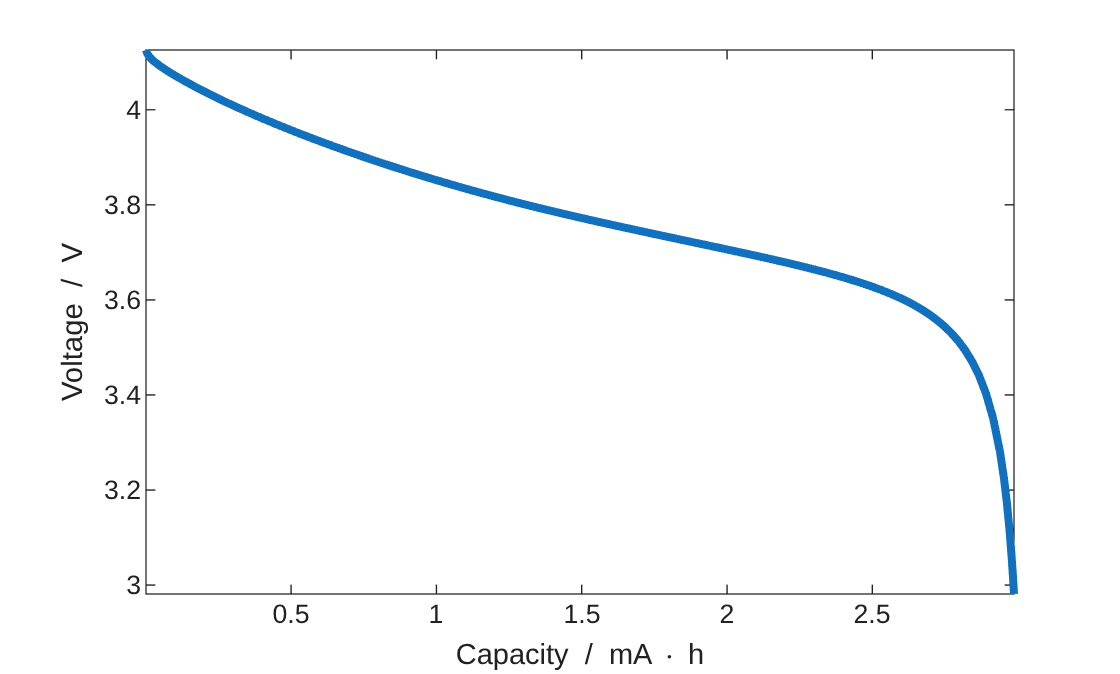

In [8]:
    % Extract the states from the output
    states = output_dis_NMC.states;


    % Extract the time, voltage, and current quantities
    time = cellfun(@(state) state.time, states);
    voltage = cellfun(@(state) state.('Control').E, states);
    current = cellfun(@(state) state.('Control').I, states);


    % Calculate the capacity
    capacity = time .* current;


    % Instantiate an empty figure
    figure()


    % Plot the discharge curve in the figure
    plot((capacity / (hour * milli)), voltage, '-', 'linewidth', 3)


    % Label the axes
    xlabel('Capacity  /  mA \cdot h')
    ylabel('Voltage  /  V')


    % Adjust the axis limits
    axis tight


<a id="H_7DB16259"></a>

### **2.2 Influence of structural and material parameters on the capacity**

For a given cell chemistry, the capacity of a cell is constrained by the number of lithium ions that can be safely intercalated and deintercalated from the electrodes. As cells age, they experience irreversible loss of lithium ions, which reduces their capacity over time. We will look at ageing mechanisms in a later chapter. Now, let's examine how material parameters affect cell capacity. One method to increase a cell's capacity, or the amount of energy stored, is by increasing the mass loading, which is the amount of active material per unit area of the electrode. This can be achieved by reducing the number of pores to increase the effective density or by increasing the mass fraction of the coating relative to other components, such as binders and additives. Alternatively, the thickness of the electrode can be increased while maintaining the same ratio of components, thereby adding more active material.

<a id="H_DC9E7650"></a>

#### **Example 4. Increasing the thickness of the negative electrode / positive electrode**

Please set the electrode type (electrodeType) to be either 'NegativeElectrode' or 'PositiveElectrode' in the code below.

**negative electrode:**

We maintain the NMC positive electrode at a constant thickness while increasing the graphite electrode thickness from 64 micrometers to 128 micrometers to observe its impact on the capacity of our 1D system. Additionally, we switch to the CC\-CV protocol, where we first charge the cell with constant current\-constant voltage (CC\-CV) and then discharge it at constant current.

We plot the discharge curve and observe that the capacity increases for 58 < 45 < 64 micrometers. However, beyond 64 micrometers, further increasing the thickness has no effect on capacity. This is because the amount of lithium in this scenario is limited by the NMC positive electrode. Although more lithium can initially intercalate into the thicker graphite, beyond a certain thickness, there is no additional lithium available to intercalate into the graphite that can be extracted during discharge. Therefore, the capacity remains unchanged.

**positive electrode:**

We increase the thickness of the NMC positive electrode from 58 micrometers to 128 micrometers. In this scenario, the negative electrode is intentionally oversized relative to the capacity of the positive electrode by approximately 1.3 times. This design ensures that the capacity of the negative electrode exceeds that of the positive electrode, thereby helping to prevent dangerous lithium plating \[4\].

The thicker electrode indeed shows a notable increase in capacity. However, this comes with its own set of challenges. The longer diffusion pathways for lithium ions within the electrode, higher overpotentials, and extended paths for electronic transport all contribute to a reduced rate capacity.  Despite the increase in energy density, these factors cause the capacity to diminish more rapidly at higher discharge rates, this makes it unsuitable for high power applications. We can see this for 128 micrometer electrode, the capacity has decreased significantly, for a C\-rate of 1.


In [9]:
% create a vector of diffent thickness values
thickness = [58,64,72,128].*micro;
markers={'-','o',"x","-"};
jsonstruct_default = parseBattmoJson('Examples/JsonDataFiles/sample_input.json');
cccv_control_protocol = parseBattmoJson('cccv_control_charge.json');%loads the CCCV protocol
jsonstruct_modified = mergeStructs({cccv_control_protocol, jsonstruct_default});

mergeStructs: Parameter Control.controlPolicy is assigned twice with different values. Value from first jsonstruct is used.
mergeStructs: Parameter Control.upperCutoffVoltage is assigned twice with different values 4.2 and 4.1, relative difference is 0.0120482. Value from first jsonstruct is used.
mergeStructs: Parameter Control.dIdtLimit is assigned twice with different values 1e-06 and 0.01, relative difference is 0.9998. Value from first jsonstruct is used.
mergeStructs: Parameter Control.dEdtLimit is assigned twice with different values 1e-06 and 0.01, relative difference is 0.9998. Value from first jsonstruct is used.
mergeStructs: Parameter SOC is assigned twice with different values 0 and 0.99, relative difference is 1. Value from first jsonstruct is used.

In [10]:
% instantiate an empty cell array to store the outputs of the simulations
output_struc = cell(size(thickness));


% instantiate an empty figure
figure()
markers = {'-', '-', '-', '-'};


% Select the type of electrode to modify
electrodeType = 'PositiveElectrode'; % or 'PositiveElectrode'
dischargeRate ='default'; % or 'default'


% use a for-loop to iterate through the vector of thickness
for i = 1 : numel(thickness)
    % Modify the value for the coating thickness for the specified electrode type
    if strcmp(electrodeType, 'NegativeElectrode')
        jsonstruct_modified.NegativeElectrode.Coating.thickness = thickness(i);
    elseif strcmp(electrodeType, 'PositiveElectrode')
        if strcmp(dischargeRate, 'high')
            jsonstruct_modified.Control.CRate=5;
        end
        jsonstruct_modified.PositiveElectrode.Coating.thickness = thickness(i);
        jsonstruct_modified.NegativeElectrode.Coating.thickness = thickness(i)*1.3;
    else
        error('Unknown electrode type specified');
    end

    % run the simulation and store the results in the output cell array
    output_struc{i} = runBattery(jsonstruct_modified);

    % retrieve the states from the simulation result
    states = output_struc{i}.states;
    disp(jsonstruct_modified.Control.CRate);
    % extract the time and voltage quantities
    time = cellfun(@(state) state.time, states);
    voltage = cellfun(@(state) state.('Control').E, states);
    current = cellfun(@(state) state.('Control').I, states);
    % calculate the capacity and plot only the capacity during discharge,
    start_index_current_pos=find(current >= 0, 1);
    time_discharge=time(start_index_current_pos);
    discharge_capacity = (time-time_discharge) .* current;
    start_index = find(discharge_capacity == 0, 1);
    end_index = find(discharge_capacity > 0, 1,"last");
    plot(discharge_capacity(start_index:end_index)/(hour*milli),voltage(start_index:end_index), markers{i}, 'linewidth', 3)
    hold on
end


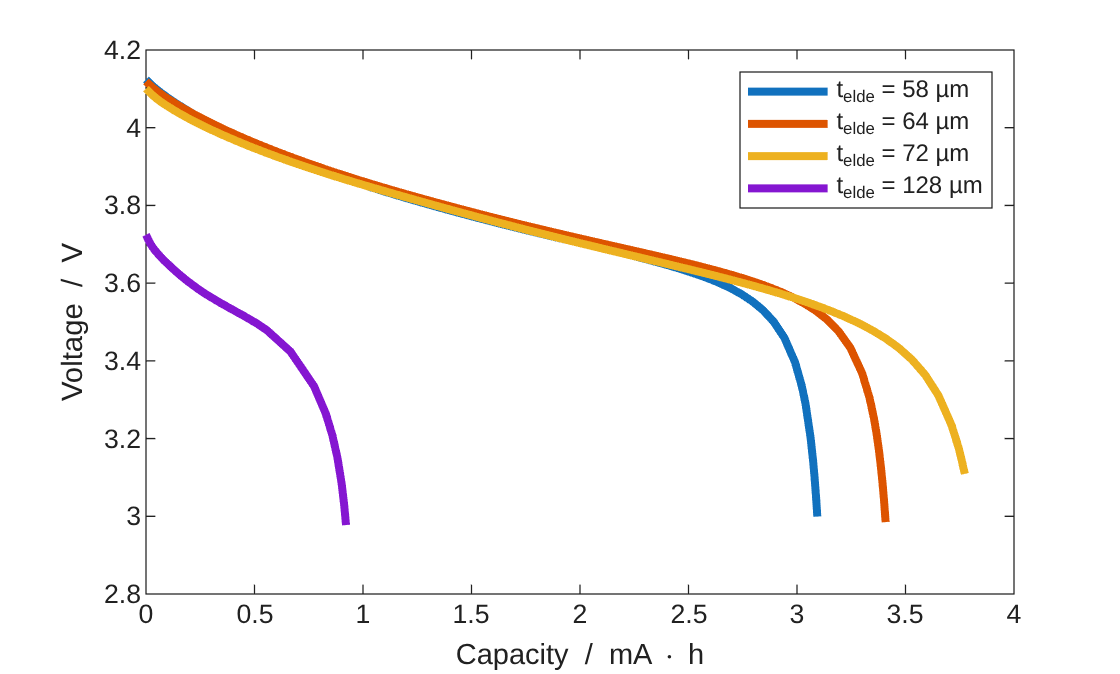

In [11]:
hold off
xlabel('Capacity  /  mA \cdot h')
ylabel('Voltage  /  V')
legend( 't_{elde} = 58 µm', 't_{elde} = 64 µm','t_{elde} = 72 µm','t_{elde} = 128 µm')

<a id="H_9FA728A8"></a>

#### **Example 5. Increasing the effective density of electrode coating**

The effective density of the electrode coating comprises both the active material and the pores. A crucial aspect of cell design is optimizing the ratio of pores to active material. While increasing the amount of active material enhances capacity and energy density by providing more lithium atoms, a less porous electrode reduces the electrolyte volume fraction. This reduction can impair the rate of ion transfer, leading to lower power densities and potential issues with the electrode’s mechanical stability. The density of the positive electrode, NMC is typically around 4650 kg/m³. To assess the impact of effective density on capacity, we vary it from 3500 to 4000 kg/m³. As discussed earlier, the electrolyte fills the pores between the electrode active particles. Therefore, increasing the effective density indefinitely is not possible, as it would reduce the electrolyte volume and hinder the transport of Li\-ions. In the plot shown below, we observe that the calculation does not converge for an effective density of 4000 kg/m³. Additionally, we have plotted the carrier concentration in the electrolyte, revealing the depletion of ions within it.


In [12]:
jsonstruct = parseBattmoJson('Examples/JsonDataFiles/sample_input.json');% parse the sample_input.json for default values.
effective_density = [3500,3700,4000];
markers={'-',"-",'-'};
% Create two figures
figure1 = figure; % For capacity vs voltage
figure2 = figure; % For x vs c
output_dens = cell(size(effective_density));
timestep=10;
% use a for-loop to iterate through the vector of effective density
for i = 1 : numel(effective_density)
    % Modify the value for the coating thickness for the positiv electrode
    jsonstruct.PositiveElectrode.Coating.effectiveDensity = effective_density(i);
    % run the simulation and store the results in the output cell array
    output_dens{i} = runBattery(jsonstruct);
    % retrieve the states from the simulation result
    states = output_dens{i}.states;
    % extract the time and voltage quantities
    time = cellfun(@(state) state.time, states);
    voltage = cellfun(@(state) state.('Control').E, states);
    current = cellfun(@(state) state.('Control').I, states);
    % calculate the capacity
    capacity = time .* current;
    % plot capacity vs voltage
    % instantiate an empty figure
    figure(figure1)
    hold on
    plot((capacity/(hour*milli)), voltage, markers{i}, 'linewidth', 3);
    title('Capacity vs Voltage');
    xlabel('Capacity  /  mA \cdot h')
    ylabel('Voltage  /  V')
    legend( 'eff-dens = 3500', 'eff-dens = 3700','eff-dens = 4000');
    figure(figure2)
    hold on
    x = output_dens{i}.model.grid.cells.centroids;
    c = output_dens{i}.states{5}.Electrolyte.c;  %at timestep 5
    plot(x, c, 'LineWidth', 3);
    title('Position vs Concentration in Electrolyte');
    xlabel('Position  /  m')
    ylabel('Concentration  /  mol \cdot m^{-3}')
    legend( 'eff-dens = 3500', 'eff-dens = 3700','eff-dens = 4000');
end

<a id="H_E6DDED54"></a>

#### **Example 6. Influence of material chemistry on capacity**

Let's now replace the positive electrode material NMC 811 with LiFePO4 (LFP) \[2\]. Different positive electrode materials have varying lithium saturation concentrations, reaction rate constants, and densities. LFP has a lower density and a lower lithium ion saturation concentration compared to NMC 811. As a result, we expect to observe a lower capacity with LFP. Additionally, the shape of the discharge curve will differ, reflecting the distinct electrochemical behavior of LFP compared to NMC 811.


In [13]:
positive_electrode_materials = ["NMC","LFP"];
markers={'-',"-",};
output_mat = cell(size(positive_electrode_materials));
% instantiate an empty figure
figure()
% use a for-loop to iterate through the vector of positive electrode materials
for i = 1:numel(positive_electrode_materials)
    % Parse the sample input JSON for default values, not the default
    % material used here is NMC
    jsonstruct = parseBattmoJson('Examples/JsonDataFiles/sample_input.json');
    if positive_electrode_materials(i) == "LFP"
        % Load the LFP json parameters
        lfp = parseBattmoJson('ParameterData/MaterialProperties/LFP/LFP_Xu2015.json');
        jsonstruct_lfp.PositiveElectrode.Coating.ActiveMaterial.Interface = lfp;
       jsonstruct = mergeStructs({jsonstruct_lfp, jsonstruct});
       jsonstruct.PositiveElectrode.Coating.ActiveMaterial.density = jsonstruct.PositiveElectrode.Coating.ActiveMaterial.Interface.density;
       % the effective density also needs to be changed here for
       % the new material
       jsonstruct.PositiveElectrode.Coating.effectiveDensity = 2709;
    end
        % Run the simulation and store the results in the output cell array
        output_mat{i} = runBattery(jsonstruct);
        % Retrieve the states from the simulation result
        states = output_mat{i}.states;
        % Extract time and voltage quantities
        time = cellfun(@(state) state.time, states);
        voltage = cellfun(@(state) state.('Control').E, states);
        current = cellfun(@(state) state.('Control').I, states);
        % Calculate the capacity
        capacity = time .* current;
        % plot capacity vs voltage
        plot((capacity/(hour*milli)), voltage, markers{i}, 'linewidth', 3);
    hold on
end


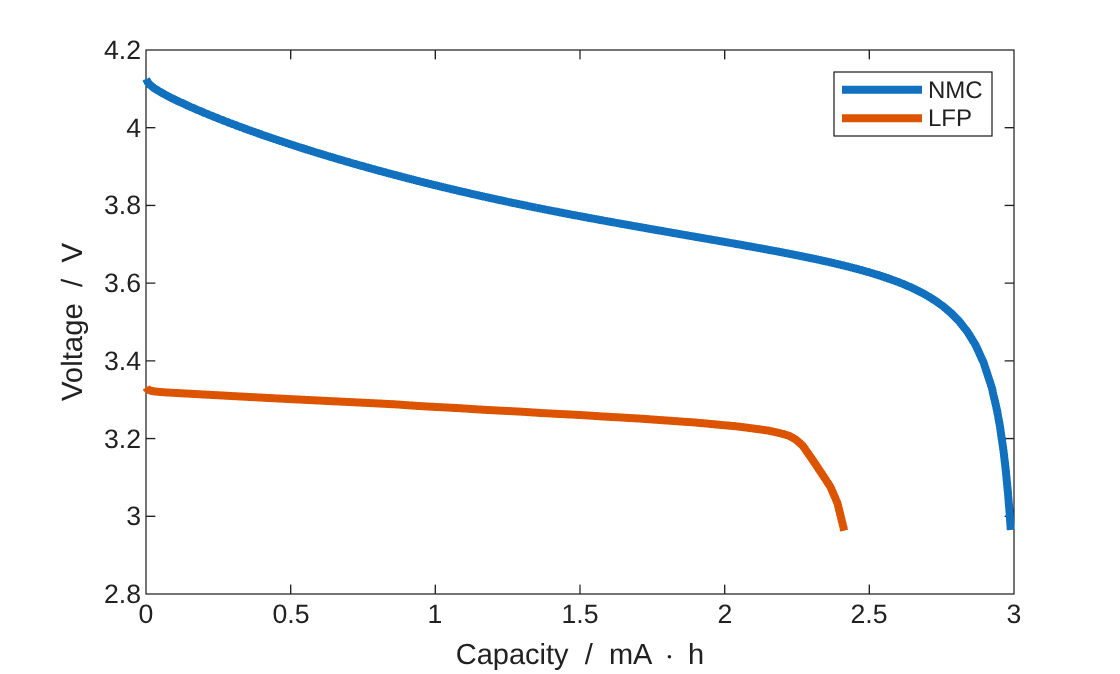

In [14]:
hold off
xlabel('Capacity  /  mA \cdot h')
ylabel('Voltage  /  V')
legend( 'NMC', 'LFP')


As expected, we observe that the capacity of LiFePO4 (LFP) is lower compared to NMC, and the maximum open\-circuit voltage (OCP) for the LFP\-graphite system is also less than that of the NMC positive electrode. Additionally, the discharge curve for LFP is flatter, indicating that the voltage remains more constant throughout the discharge cycle compared to NMC.

<a id="H_2C76BCB3"></a>

### 3. Summary

We covered the fundamentals of battery components and common terminology used in the battery field. Using BattMo, we visualized the structure of a battery and ran simulations with the default parameter set. Additionally, we explored the structural and material properties of the cell to understand their impact on cell voltage.In the next guide, we will delve into the model equations used in BattMo, which are based on the Doyle\-Fuller\-Newman (DFN) model.

<a id="H_BACA0C3A"></a>

### **4. References**

\[1\] [Flores Cedeño, E. J. (2020). *Development of operando diagnostics for Li\-ion positive electrodes by Raman spectroscopy* (Doctoral thesis, ETH Zurich).](https://doi.org/10.3929/ethz-b-000373382)

\[2\] [Safari, M., et al. "Multimodal physics–based aging model for life prediction of Li–ion batteries." Journal of The Electrochemical Society 156.3 (2008): A145.](https://iopscience.iop.org/article/10.1149/1.3043429/meta)

\[3\] [Xu, Meng, et al. "A pseudo three–dimensional electrochemical–thermal model of a prismatic LiFePO4 battery during discharge process." Energy 80 (2015): 303–317.](<https://www.sciencedirect.com/science/article/pii/S0360544214013437#sec2.6.1>)

\[4\] [Karin Kleiner, Peter Jakes, Sebastian Scharner, Verena Liebau, Helmut Ehrenberg, "Changes of the balancing between negative electrode and positive electrode due to fatigue in commercial lithium\-ion cells," *Journal of Power Sources*, Volume 317, 2016, Pages 25\-34, ISSN 0378\-7753, https://doi.org/10.1016/j.jpowsour.2016.03.049. ](https://www.sciencedirect.com/science/article/pii/S0378775316302506)

\[5\] [Z. Khalik, M.C.F. Donkers, H.J. Bergvel (2021). "Model simplifications and their impact on computational complexity for an electrochemistry\-based battery modeling toolbox" *Journal of Power Sources*, 488, 229427](<https://www.sciencedirect.com/science/article/pii/S0378775320317018?via%3Dihub#fig1>). [https://doi.org/10.1016/j.jpowsour.2020.229427.](https://doi.org/10.1016/j.jpowsour.2020.229427.)

\[6\] [Z. Chen, D. L. Danilov, R.\-A. Eichel, P. H. L. Notten, Porous Electrode Modeling and its Applications to Li\-Ion Batteries. *Adv. Energy Mater.* 2022, 12, 2201506. https://doi.org/10.1002/aenm.202201506](https://onlinelibrary.wiley.com/doi/full/10.1002/aenm.202201506)

\[7\] [A. Sobkowiak, ‘LiFeSO4F as a Cathode Material for Lithium\-Ion Batteries : Synthesis, Structure, and Function’, PhD dissertation, Acta Universitatis Upsaliensis, Uppsala, 2015.](https://uu.diva-portal.org/smash/record.jsf?pid=diva2%3A855021&dswid=3714)